# Solving the 1D Transient Heat Equation with Hard-Constrained PINNs (hPINNs)

This notebook solves the 1D heat equation using a hard-constrained physics-informed neural network (hPINN). Unlike soft-constrained PINNs, which use penalty terms in the loss function, hPINNs enforce the boundary and initial conditions by construction.

- **Domain**: $\Omega = [0, 1] \text{ and } t = [0, 1]$
- **Boundary Conditions**: $u(x = 0, t) = u(x = 1, t) = 0$
- **Initial Conditions**: $u(x, t = 0) = \sin(\pi x)$

## Hard-Constraint Formulation

We define a trial solution $u_{trial}(x, t)$ that already satisfies the BCs and ICs. Let $NN(x, t)$ be the output of a neural network. We can define our trial solution as:
$$ u_{trial}(x, t) = (1 - t) \sin(\pi x) + x(1 - x)t \cdot NN(x, t) $$

Let's check the conditions:
- **BC at x=0:** $u_{trial}(0, t) = (1 - t) \sin(0) + 0 \cdot (1 - 0) \cdot t \cdot NN(0, t) = 0$
- **BC at x=1:** $u_{trial}(1, t) = (1 - t) \sin(\pi) + 1 \cdot (1 - 1) \cdot t \cdot NN(1, t) = 0$
- **IC at t=0:** $u_{trial}(x, 0) = (1 - 0) \sin(\pi x) + x(1 - x) \cdot 0 \cdot NN(x, 0) = \sin(\pi x)$

Since the trial solution satisfies the BCs and ICs by construction, we only need to train the network to minimize the PDE residual.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Hyperparameters
layers = [2, 50, 50, 50, 1]  # 2 input (x, t), 3 hidden layers with 50 neurons, 1 output (u)
alpha = 0.1  # Thermal diffusivity
learning_rate = 0.001
epochs = 1000

# Generate collocation points
x_collocation = torch.linspace(0, 1, 10).reshape(-1, 1)
t_collocation = torch.linspace(0, 1, 10).reshape(-1, 1)
x_collocation, t_collocation = torch.meshgrid(x_collocation.squeeze(), t_collocation.squeeze(), indexing='ij')
x_collocation = x_collocation.reshape(-1, 1)
t_collocation = t_collocation.reshape(-1, 1)

# Ensure requires_grad is True for collocation points
x_collocation.requires_grad = True
t_collocation.requires_grad = True

### Define the hPINN model

In [3]:
class hPINN(nn.Module):
    def __init__(self, layers):
        super(hPINN, self).__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 1):
            self.net.add_module(f"linear_{i}", nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                self.net.add_module(f"tanh_{i}", nn.Tanh())

    def forward(self, x, t):
        nn_output = self.net(torch.cat([x, t], dim=1))
        # Trial solution that satisfies BCs and ICs
        u_trial = (1 - t) * torch.sin(torch.pi * x) + x * (1 - x) * t * nn_output
        return u_trial

# Initialize model and optimizer
model = hPINN(layers)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

### Define the PDE loss function

In [4]:
def pde_loss(model, x, t, alpha):
    u = model(x, t)
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    # Residual of the PDE
    f = u_t - alpha * u_xx
    return torch.mean(f ** 2)

### Training Loop
The training loop is simpler as we only need to minimize the PDE loss.

In [5]:
losses = []
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Compute PDE loss
    loss = pde_loss(model, x_collocation, t_collocation, alpha)
    
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.12375133484601974
Epoch 100, Loss: 0.0052052889950573444
Epoch 200, Loss: 0.002062693238258362
Epoch 300, Loss: 0.00016962940571829677
Epoch 400, Loss: 0.00012819604307878762
Epoch 500, Loss: 9.886785119306296e-05
Epoch 600, Loss: 7.944032404338941e-05
Epoch 700, Loss: 6.618381303269416e-05
Epoch 800, Loss: 5.6146931456169114e-05
Epoch 900, Loss: 4.748217907035723e-05


### Visualization and Comparison

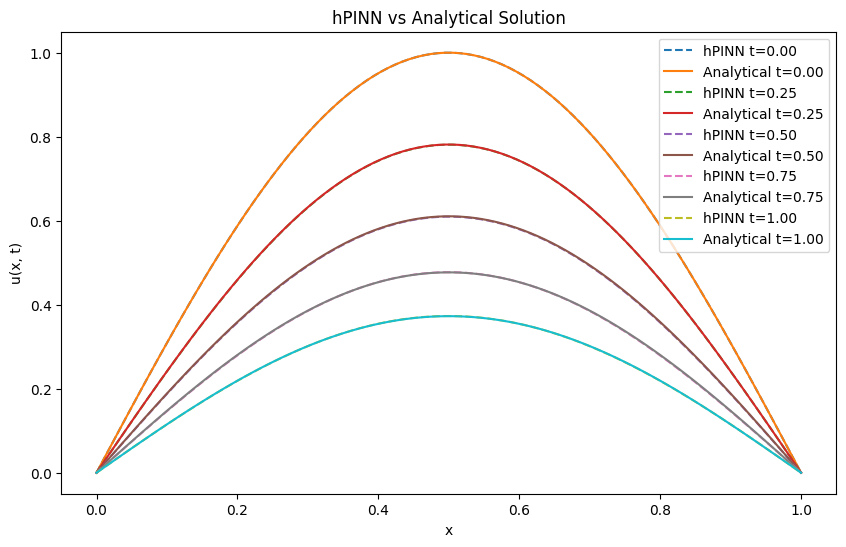

In [6]:
def analytical_solution(x, t, alpha):
    return torch.exp(-alpha * torch.pi**2 * t) * torch.sin(torch.pi * x)

model.eval()
x_test = torch.linspace(0, 1, 100).reshape(-1, 1)
timesteps = [0, 0.25, 0.5, 0.75, 1.0]

plt.figure(figsize=(10, 6))
for t_val in timesteps:
    t_test = torch.full_like(x_test, t_val)
    u_pred = model(x_test, t_test).detach().numpy()
    u_exact = analytical_solution(x_test, t_test, alpha).detach().numpy()
    plt.plot(x_test.numpy(), u_pred, '--', label=f'hPINN t={t_val:.2f}')
    plt.plot(x_test.numpy(), u_exact, label=f'Analytical t={t_val:.2f}')

plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title('hPINN vs Analytical Solution')
plt.legend()
plt.show()